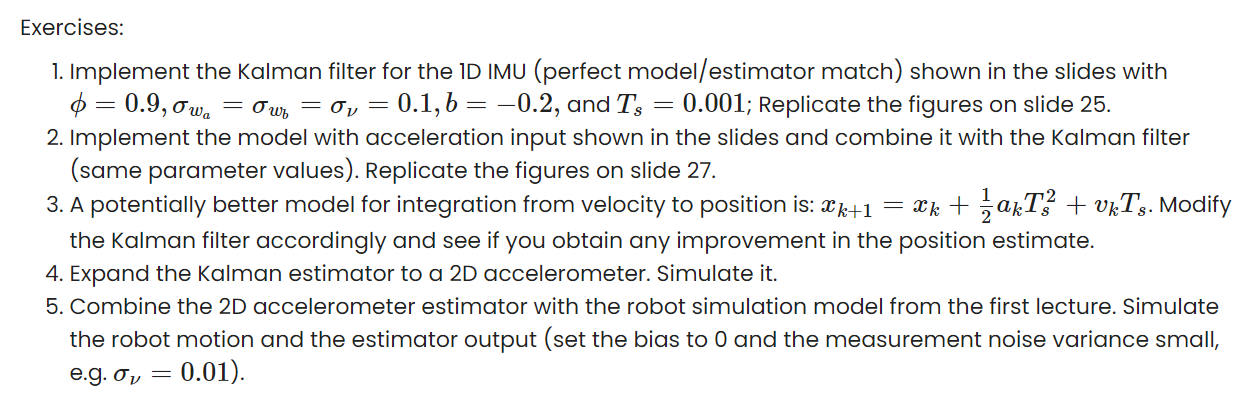

In [1]:
phi = 0.9
SD_a = 0.1
SD_b = 0.001
SD_v = 0.1
b = -0.2
Ts = 0.01

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

rng = np.random.default_rng(42)
N   = 5000

## Task 1: 1D IMU KF — state [a, b]
Perfect model/estimator match. Replicate slide 25.

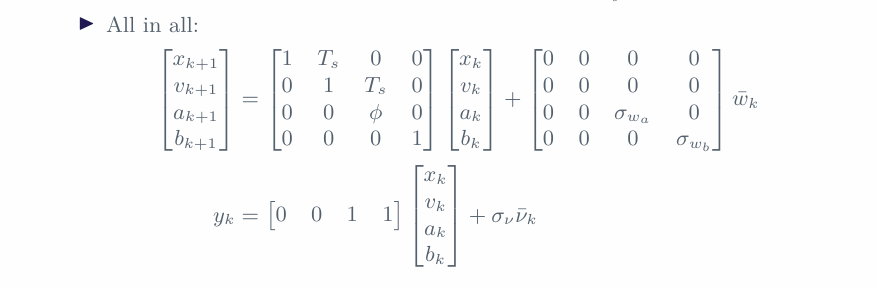

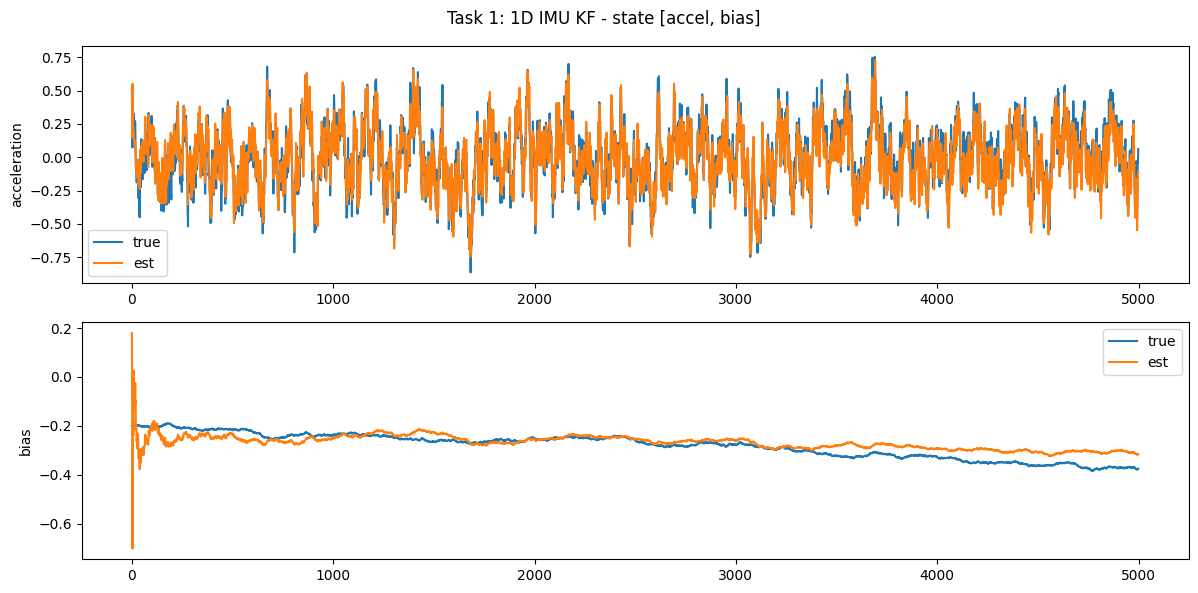

In [3]:
# Task 1: estimate acceleration and bias from noisy measurement
# state: [accel, bias]
# accel: AR(1) process
# bias:  random walk
# measurement: accel + bias + noise

Phi_1 = np.array([[phi, 0.0],
                   [0.0, 1.0]])
Q_1   = np.diag([SD_a**2, SD_b**2])
H_1   = np.array([[1.0, 1.0]])
R_1   = np.array([[SD_v**2]])

state_true = np.array([[0.5], [b]]) # initial state

true_a = np.zeros(N)
true_b = np.zeros(N)
z_1    = np.zeros(N)

for k in range(N):
    true_a[k] = state_true[0, 0]
    true_b[k] = state_true[1, 0]
    z_1[k]    = (H_1 @ state_true)[0, 0] + SD_v * rng.standard_normal()
    w = np.array([[SD_a * rng.standard_normal()],
                  [SD_b * rng.standard_normal()]])
    state_true = Phi_1 @ state_true + w

state_est_1 = np.zeros((2, 1))
P_1 = np.eye(2)
est_a = np.zeros(N)
est_b = np.zeros(N)

for k in range(N):
    # predict
    state_est_1 = Phi_1 @ state_est_1
    P_1 = Phi_1 @ P_1 @ Phi_1.T + Q_1
    # update
    innov = z_1[k] - (H_1 @ state_est_1)[0, 0]
    S = H_1 @ P_1 @ H_1.T + R_1
    K = P_1 @ H_1.T @ np.linalg.inv(S)
    state_est_1 = state_est_1 + K * innov
    IKH = np.eye(2) - K @ H_1
    P_1 = IKH @ P_1 @ IKH.T + K @ R_1 @ K.T
    est_a[k] = state_est_1[0, 0]
    est_b[k] = state_est_1[1, 0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle("Task 1: 1D IMU KF - state [accel, bias]")
axes[0].plot(true_a, label="true"); axes[0].plot(est_a, label="est")
axes[0].set_ylabel("acceleration"); axes[0].legend()
axes[1].plot(true_b, label="true"); axes[1].plot(est_b, label="est")
axes[1].set_ylabel("bias"); axes[1].legend()
plt.tight_layout(); plt.show()

## Task 2: 1D IMU with position/velocity — state [x, v, a, b]
Acceleration input drives position. Replicate slide 27.

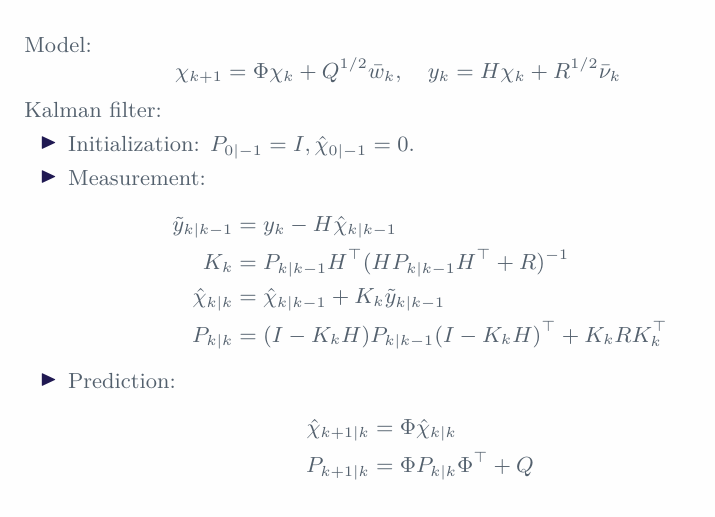

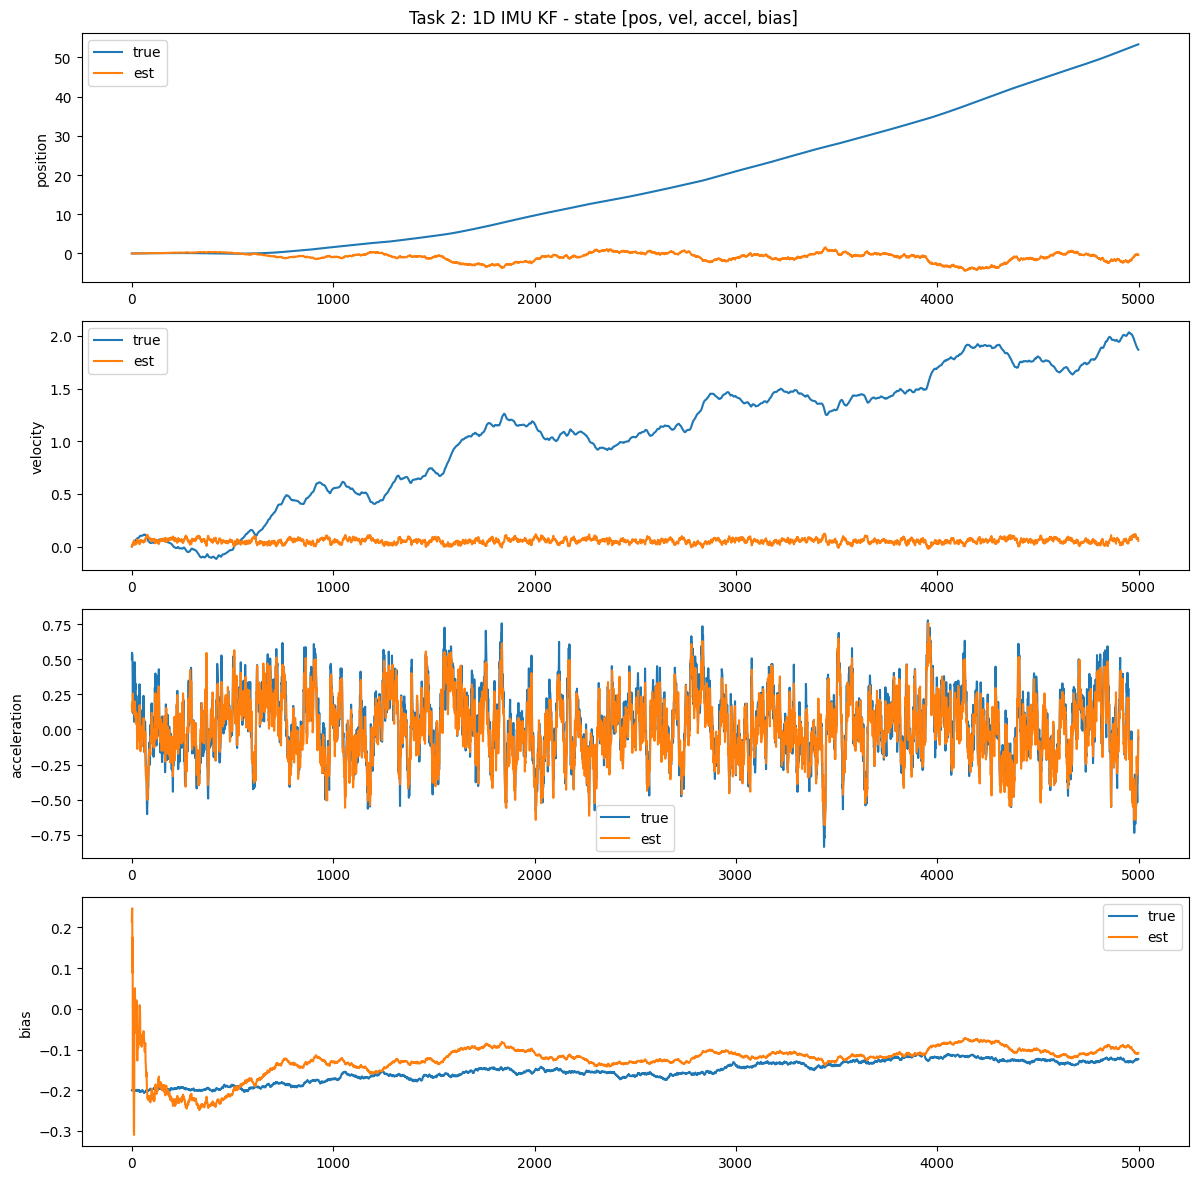

In [4]:
# Task 2: add position and velocity to state
# state: [pos, vel, accel, bias]
# position integrates velocity, velocity integrates acceleration
# only acceleration+bias is measured

Phi_2 = np.array([[1, Ts,  0,   0],
                   [0,  1, Ts,   0],
                   [0,  0, phi,  0],
                   [0,  0,  0,   1]])
Q_2 = np.diag([0.0, 0.0, SD_a**2, SD_b**2])
H_2 = np.array([[0, 0, 1, 1]])   # measures accel + bias
R_2 = np.array([[SD_v**2]])

state_true_2 = np.array([[0.0], [0.0], [0.5], [b]])
true_2 = np.zeros((4, N))
z_2    = np.zeros(N)

for k in range(N):
    true_2[:, k] = state_true_2[:, 0]
    z_2[k] = (H_2 @ state_true_2)[0, 0] + SD_v * rng.standard_normal()
    w = np.array([[0.0], [0.0],
                  [SD_a * rng.standard_normal()],
                  [SD_b * rng.standard_normal()]])
    state_true_2 = Phi_2 @ state_true_2 + w

state_est_2 = np.zeros((4, 1))
P_2 = np.eye(4)
est_2 = np.zeros((4, N))

for k in range(N):
    # predict
    state_est_2 = Phi_2 @ state_est_2
    P_2 = Phi_2 @ P_2 @ Phi_2.T + Q_2
    # update
    innov = z_2[k] - (H_2 @ state_est_2)[0, 0]
    S = H_2 @ P_2 @ H_2.T + R_2
    K = P_2 @ H_2.T @ np.linalg.inv(S)
    state_est_2 = state_est_2 + K * innov
    IKH = np.eye(4) - K @ H_2
    P_2 = IKH @ P_2 @ IKH.T + K @ R_2 @ K.T
    est_2[:, k] = state_est_2[:, 0]

fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle("Task 2: 1D IMU KF - state [pos, vel, accel, bias]")
for i, label in enumerate(["position", "velocity", "acceleration", "bias"]):
    axes[i].plot(true_2[i], label="true"); axes[i].plot(est_2[i], label="est")
    axes[i].set_ylabel(label); axes[i].legend()
plt.tight_layout(); plt.show()

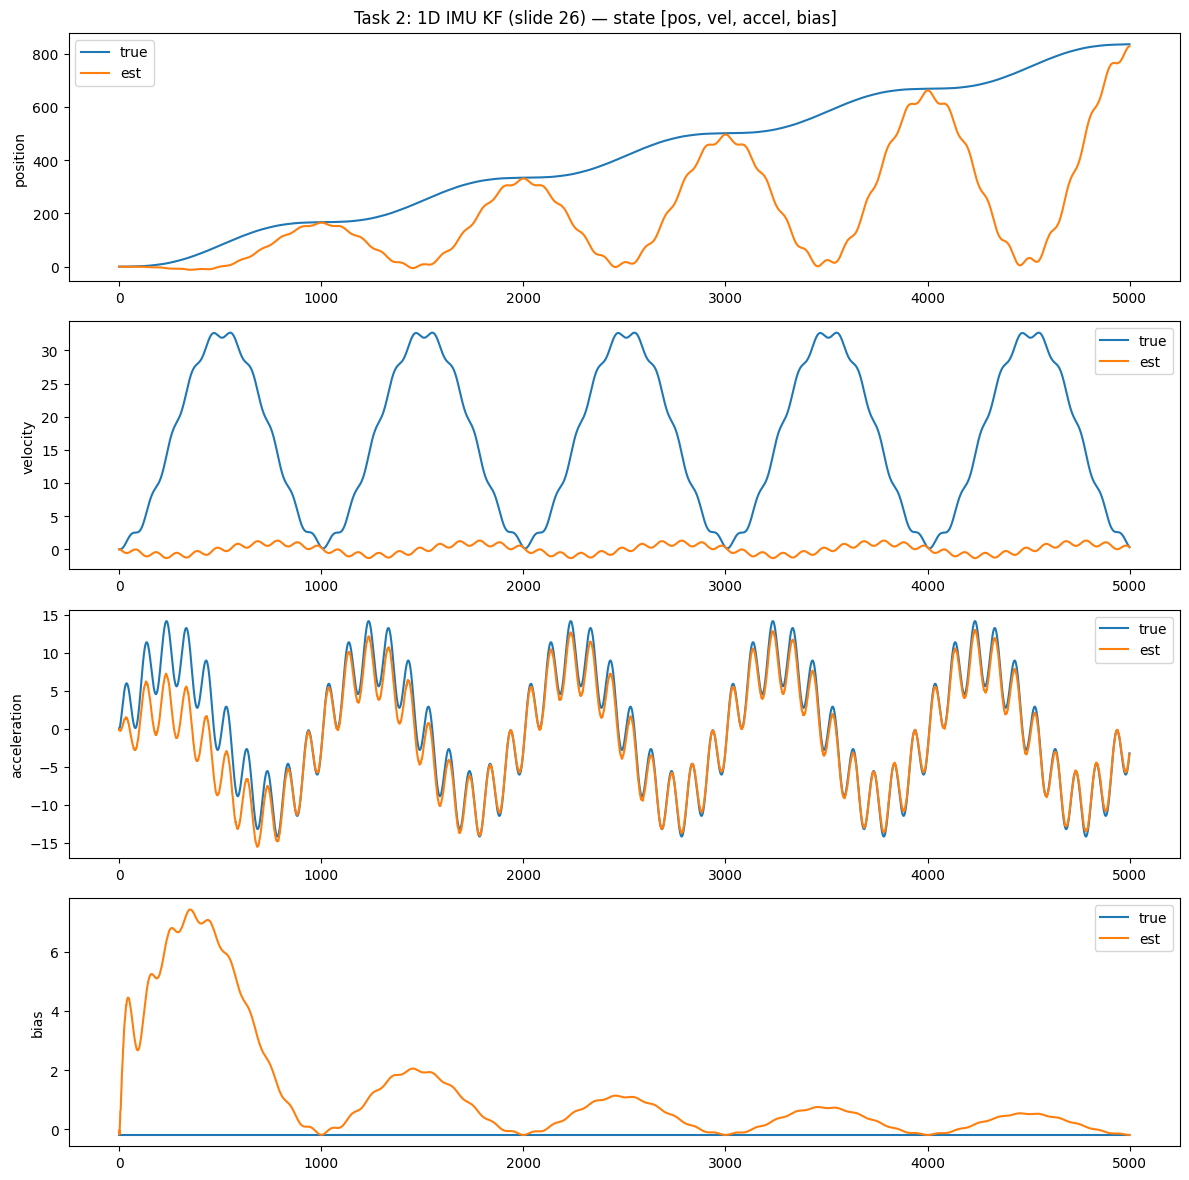

In [5]:
# Task 2 (slide 26): acceleration as external input via Gamma
# state: [pos, vel, accel, bias]
# Both true system and filter share the same Phi (Phi[2,2]=0, no AR(1) self-propagation)
# True system: accel state is driven by AR(1) input a_k (known to system, unknown to filter)
# Filter: uses acceleration_input=0 since it has no independent acceleration source

Phi_2   = np.array([[1, Ts, 0, 0],
                    [0,  1, Ts, 0],
                    [0,  0,  phi, 0],   # accel does not self-propagate
                    [0,  0,  0, 1]])
Gamma_2 = np.array([[0.0], [0.0], [1.0], [0.0]])   # a_k feeds directly into accel state

Q_2 = np.diag([0.0, 0.0, SD_a**2, 0])
H_2 = np.array([[0, 0, 1, 1]])   # measures accel + bias
R_2 = np.array([[SD_v**2]])

# --- generate external acceleration as AR(1): a_{k+1} = phi*a_k + w_a ---
true_accel_input = np.zeros(N)

# --- true system driven by true_accel_input via Gamma_2 ---
state_true_2 = np.array([[0.0], [0.0], [0], [b]])
true_2 = np.zeros((4, N))
z_2    = np.zeros(N)

for k in range(N):
    true_accel_input[k] = 0.5*np.sin(2*np.pi*Ts*k) + np.sin(2*np.pi*(Ts/10)*k) # example: sinusoidal acceleration input


for k in range(N):
    true_2[:, k] = state_true_2[:, 0]
    z_2[k] = (H_2 @ state_true_2)[0, 0] + SD_v * rng.standard_normal()
    # w_bias = np.array([[0.0], [0.0], [0.0], [SD_b * rng.standard_normal()]])
    state_true_2 = Phi_2 @ state_true_2 + Gamma_2 * true_accel_input[k]

# --- Kalman filter: a_k unknown to filter, so acceleration_input=0 ---
state_est_2 = np.zeros((4, 1))
P_2 = np.eye(4)
est_2 = np.zeros((4, N))

for k in range(N):
    state_est_2 = Phi_2 @ state_est_2
    P_2 = Phi_2 @ P_2 @ Phi_2.T + Q_2
    innov = z_2[k] - (H_2 @ state_est_2)[0, 0]
    S = H_2 @ P_2 @ H_2.T + R_2
    K = P_2 @ H_2.T @ np.linalg.inv(S)
    state_est_2 = state_est_2 + K * innov
    IKH = np.eye(4) - K @ H_2
    P_2 = IKH @ P_2 @ IKH.T + K @ R_2 @ K.T
    est_2[:, k] = state_est_2[:, 0]

fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle("Task 2: 1D IMU KF (slide 26) — state [pos, vel, accel, bias]")
for i, label in enumerate(["position", "velocity", "acceleration", "bias"]):
    axes[i].plot(true_2[i], label="true"); axes[i].plot(est_2[i], label="est")
    axes[i].set_ylabel(label); axes[i].legend()
plt.tight_layout(); plt.show()

## Task 3: Better position integration
`x_{k+1} = x_k + v_k·Ts + ½·a_k·Ts²`  — compare position RMSE.

Ts^2 term = 5.00e-05  vs  Ts = 0.01  -> negligible improvement at Ts=0.001
RMSE simple:  3.120244
RMSE better:  3.120283


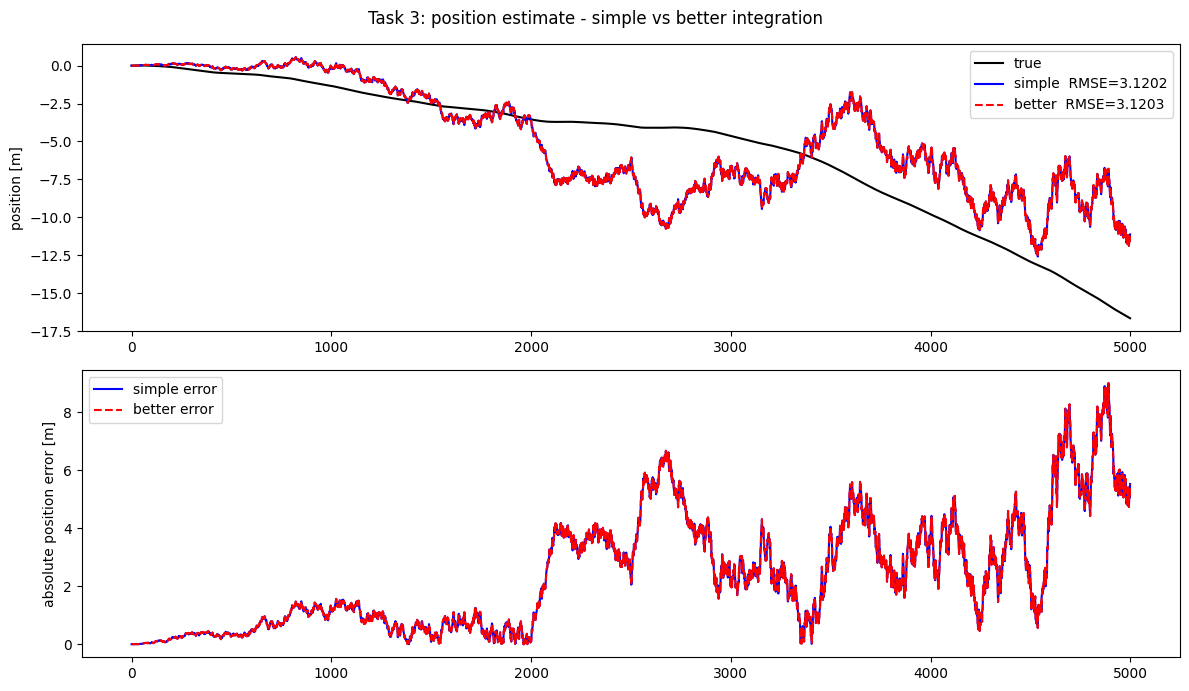

In [6]:
# Task 3: better position integration includes 0.5*accel*Ts^2 term
# true data regenerated with better model (more accurate physics)
# compare: simple filter vs better filter on same data

Phi_3 = Phi_2.copy()
Phi_3[0, 2] = 0.5 * Ts**2   # adds accel contribution to position

rng3 = np.random.default_rng(99)
state_true_3 = np.array([[0.0], [0.0], [0.5], [b]])
true_3 = np.zeros((4, N))
z_3    = np.zeros(N)

for k in range(N):
    true_3[:, k] = state_true_3[:, 0]
    z_3[k] = (H_2 @ state_true_3)[0, 0] + SD_v * rng3.standard_normal()
    w = np.array([[0.0], [0.0],
                  [SD_a * rng3.standard_normal()],
                  [SD_b * rng3.standard_normal()]])
    state_true_3 = Phi_3 @ state_true_3 + w

# simple integration filter
est_simple = np.zeros((4, N))
se, P = np.zeros((4, 1)), np.eye(4)
for k in range(N):
    se = Phi_2 @ se; P = Phi_2 @ P @ Phi_2.T + Q_2
    inn = z_3[k] - (H_2 @ se)[0, 0]
    S = H_2 @ P @ H_2.T + R_2; K = P @ H_2.T @ np.linalg.inv(S)
    se = se + K * inn; IKH = np.eye(4) - K @ H_2
    P = IKH @ P @ IKH.T + K @ R_2 @ K.T
    est_simple[:, k] = se[:, 0]

# better integration filter
est_better = np.zeros((4, N))
se, P = np.zeros((4, 1)), np.eye(4)
for k in range(N):
    se = Phi_3 @ se; P = Phi_3 @ P @ Phi_3.T + Q_2
    inn = z_3[k] - (H_2 @ se)[0, 0]
    S = H_2 @ P @ H_2.T + R_2; K = P @ H_2.T @ np.linalg.inv(S)
    se = se + K * inn; IKH = np.eye(4) - K @ H_2
    P = IKH @ P @ IKH.T + K @ R_2 @ K.T
    est_better[:, k] = se[:, 0]

pos_rmse_2 = np.sqrt(np.mean((true_3[0] - est_simple[0])**2))
pos_rmse_3 = np.sqrt(np.mean((true_3[0] - est_better[0])**2))
print(f"Ts^2 term = {0.5*Ts**2:.2e}  vs  Ts = {Ts}  -> negligible improvement at Ts=0.001")
print(f"RMSE simple:  {pos_rmse_2:.6f}")
print(f"RMSE better:  {pos_rmse_3:.6f}")

k_axis = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle("Task 3: position estimate - simple vs better integration")
axes[0].plot(k_axis, true_3[0], "k-", label="true")
axes[0].plot(k_axis, est_simple[0], "b-", label=f"simple  RMSE={pos_rmse_2:.4f}")
axes[0].plot(k_axis, est_better[0], "r--", label=f"better  RMSE={pos_rmse_3:.4f}")
axes[0].set_ylabel("position [m]"); axes[0].legend()
axes[1].plot(k_axis, np.abs(true_3[0] - est_simple[0]), "b-", label="simple error")
axes[1].plot(k_axis, np.abs(true_3[0] - est_better[0]), "r--", label="better error")
axes[1].set_ylabel("absolute position error [m]"); axes[1].legend()
plt.tight_layout(); plt.show()

## Task 4: 2D accelerometer
Expand to state [x, vx, ax, bx, y, vy, ay, by].

  x   : RMSE=5.7407
  vx  : RMSE=0.3002
  ax  : RMSE=0.0958
  bx  : RMSE=0.0564
  y   : RMSE=6.7351
  vy  : RMSE=0.5105
  ay  : RMSE=0.0905
  by  : RMSE=0.0497


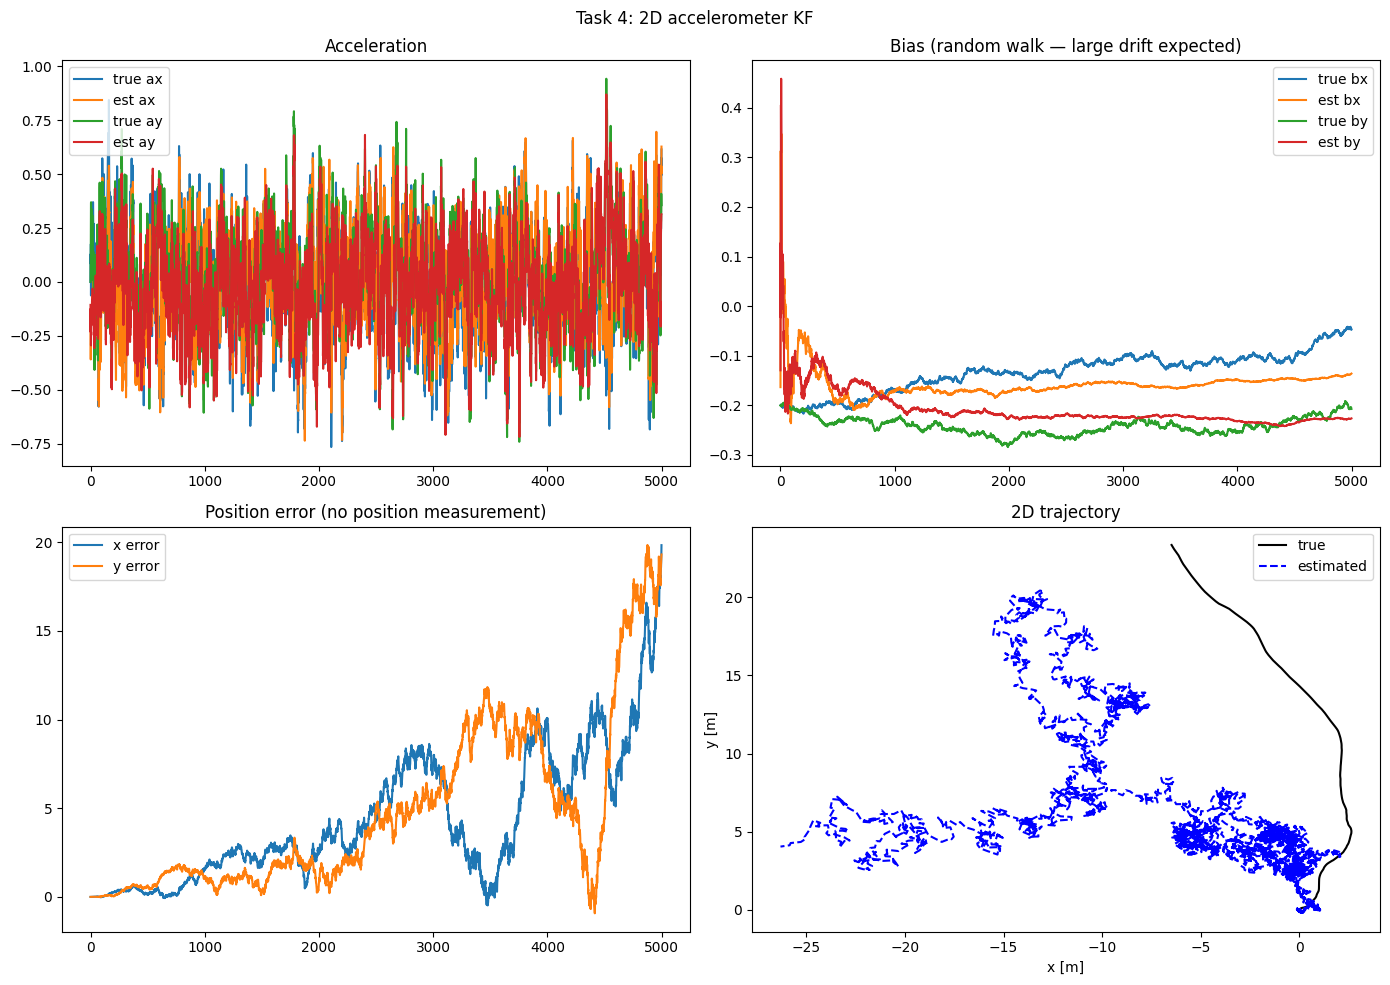

In [7]:
# Task 4: expand to 2D accelerometer
# state: [x, vx, ax, bx,  y, vy, ay, by]
# two measurements: x-accel+bias, y-accel+bias

Phi_4 = block_diag(Phi_3, Phi_3)
Q_4   = block_diag(Q_2, Q_2)
H_4   = np.zeros((2, 8))
H_4[0, 2] = 1; H_4[0, 3] = 1   # z_x = ax + bx
H_4[1, 6] = 1; H_4[1, 7] = 1   # z_y = ay + by
R_4 = np.diag([SD_v**2, SD_v**2])

rng4 = np.random.default_rng(123)
state_true_4 = np.array([[0.0], [0.0], [0], [b],
                           [0.0], [0.0], [0], [b]])
true_4 = np.zeros((8, N))
z_4    = np.zeros((2, N))

for k in range(N):
    true_4[:, k] = state_true_4[:, 0]
    z_4[:, k] = (H_4 @ state_true_4)[:, 0] + SD_v * rng4.standard_normal(2)
    w = np.zeros((8, 1))
    w[2, 0] = SD_a * rng4.standard_normal(); w[3, 0] = SD_b * rng4.standard_normal()
    w[6, 0] = SD_a * rng4.standard_normal(); w[7, 0] = SD_b * rng4.standard_normal()
    state_true_4 = Phi_4 @ state_true_4 + w

state_est_4 = np.zeros((8, 1))
P_4 = np.eye(8)
est_4 = np.zeros((8, N))

for k in range(N):
    # predict
    state_est_4 = Phi_4 @ state_est_4
    P_4 = Phi_4 @ P_4 @ Phi_4.T + Q_4
    # update
    innov = z_4[:, k:k+1] - H_4 @ state_est_4
    S = H_4 @ P_4 @ H_4.T + R_4
    K = P_4 @ H_4.T @ np.linalg.inv(S)
    state_est_4 = state_est_4 + K @ innov
    IKH = np.eye(8) - K @ H_4
    P_4 = IKH @ P_4 @ IKH.T + K @ R_4 @ K.T
    est_4[:, k] = state_est_4[:, 0]

k_axis = np.arange(N)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task 4: 2D accelerometer KF")

axes[0, 0].plot(k_axis, true_4[2], label="true ax"); axes[0, 0].plot(k_axis, est_4[2], label="est ax")
axes[0, 0].plot(k_axis, true_4[6], label="true ay"); axes[0, 0].plot(k_axis, est_4[6], label="est ay")
axes[0, 0].set_title("Acceleration"); axes[0, 0].legend()

axes[0, 1].plot(k_axis, true_4[3], label="true bx"); axes[0, 1].plot(k_axis, est_4[3], label="est bx")
axes[0, 1].plot(k_axis, true_4[7], label="true by"); axes[0, 1].plot(k_axis, est_4[7], label="est by")
axes[0, 1].set_title("Bias (random walk — large drift expected)"); axes[0, 1].legend()

axes[1, 0].plot(k_axis, true_4[0] - est_4[0], label="x error")
axes[1, 0].plot(k_axis, true_4[4] - est_4[4], label="y error")
axes[1, 0].set_title("Position error (no position measurement)"); axes[1, 0].legend()

axes[1, 1].plot(true_4[0], true_4[4], "k-", label="true")
axes[1, 1].plot(est_4[0], est_4[4], "b--", label="estimated")
axes[1, 1].set_title("2D trajectory"); axes[1, 1].set_xlabel("x [m]"); axes[1, 1].set_ylabel("y [m]")
axes[1, 1].legend()

for i, name in enumerate(["x","vx","ax","bx","y","vy","ay","by"]):
    print(f"  {name:4s}: RMSE={np.sqrt(np.mean((true_4[i]-est_4[i])**2)):.4f}")

plt.tight_layout(); plt.show()

## Task 5: Robot simulation + 2D KF
Circular robot motion, b=0, σ_v=0.01.

Task 5 - 2D position RMSE: 2.0829 m  (radius=0.6m)


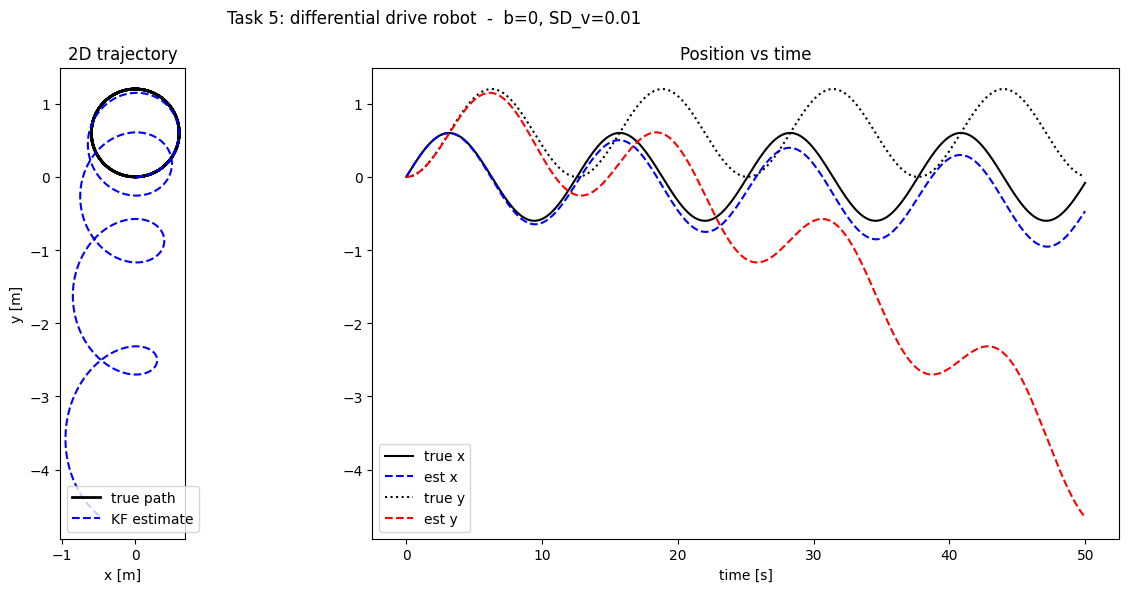

In [8]:
# Task 5: differential drive robot — 2 driven wheels at front, free caster at back
# caster follows passively; only front wheels determine v and omega
# kinematics: x += v*cos(h)*Ts,  y += v*sin(h)*Ts,  heading += omega*Ts
# accelerometer measures centripetal acceleration — no bias, low noise

v_robot     = 0.3   # linear speed [m/s]
omega_robot = 0.5   # angular rate [rad/s]
SD_v_5      = 0.01
b_5         = 0.0

t_ax = np.arange(N) * Ts

# differential drive at constant v and omega -> circular arc
heading  = omega_robot * t_ax
x_robot  = (v_robot / omega_robot) * np.sin(heading)
y_robot  = (v_robot / omega_robot) * (1 - np.cos(heading))
vx_robot =  v_robot * np.cos(heading)
vy_robot =  v_robot * np.sin(heading)
ax_robot = -v_robot * omega_robot * np.sin(heading)   # centripetal
ay_robot =  v_robot * omega_robot * np.cos(heading)   # centripetal

rng5 = np.random.default_rng(7)
z_5  = np.vstack([ax_robot + SD_v_5 * rng5.standard_normal(N),
                   ay_robot + SD_v_5 * rng5.standard_normal(N)])

# phi=1: acceleration changes slowly, trust measurements over prediction
Phi_1d_5 = np.array([[1, Ts, 0.5*Ts**2, 0],
                      [0,  1,       Ts, 0],
                      [0,  0,      1.0, 0],
                      [0,  0,      0.0, 1]])
Phi_4_5   = block_diag(Phi_1d_5, Phi_1d_5)
Q_5       = block_diag(np.diag([0.0, 0.0, SD_a**2, 0.0]),
                        np.diag([0.0, 0.0, SD_a**2, 0.0]))
R_5       = np.diag([SD_v_5**2, SD_v_5**2])

# init from true state
state_est_5 = np.array([[x_robot[0]], [vx_robot[0]], [ax_robot[0]], [b_5],
                          [y_robot[0]], [vy_robot[0]], [ay_robot[0]], [b_5]])
P_5 = np.eye(8) * 0.01
est_5 = np.zeros((8, N))

for k in range(N):
    # predict
    state_est_5 = Phi_4_5 @ state_est_5
    P_5 = Phi_4_5 @ P_5 @ Phi_4_5.T + Q_5
    # update
    innov = z_5[:, k:k+1] - H_4 @ state_est_5
    S = H_4 @ P_5 @ H_4.T + R_5
    K = P_5 @ H_4.T @ np.linalg.inv(S)
    state_est_5 = state_est_5 + K @ innov
    IKH = np.eye(8) - K @ H_4
    P_5 = IKH @ P_5 @ IKH.T + K @ R_5 @ K.T
    est_5[:, k] = state_est_5[:, 0]

pos_rmse_5 = np.sqrt(np.mean((x_robot - est_5[0])**2 + (y_robot - est_5[4])**2))
print(f"Task 5 - 2D position RMSE: {pos_rmse_5:.4f} m  (radius={v_robot/omega_robot:.1f}m)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Task 5: differential drive robot  -  b=0, SD_v=0.01")
axes[0].plot(x_robot, y_robot, "k-", linewidth=2, label="true path")
axes[0].plot(est_5[0], est_5[4], "b--", label="KF estimate")
axes[0].set_title("2D trajectory"); axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal"); axes[0].legend()
axes[1].plot(t_ax, x_robot, "k-", label="true x"); axes[1].plot(t_ax, est_5[0], "b--", label="est x")
axes[1].plot(t_ax, y_robot, "k:", label="true y"); axes[1].plot(t_ax, est_5[4], "r--", label="est y")
axes[1].set_title("Position vs time"); axes[1].set_xlabel("time [s]"); axes[1].legend()
plt.tight_layout(); plt.show()

**Reflection:**
1. Task 1: bias is *observed* — the filter estimates it from measurements so it can correct the acceleration estimate.
2. Tasks 2–3: one bias parameter is estimated per axis; it corrects the integrated position/velocity via the measurement update, not directly per-state.
3. Task 3: better integration includes the `0.5*a*Ts^2` term in position propagation — reduces position drift especially when acceleration is large.
4. Task 4: extending to 2D is a block-diagonal structure; x and y channels are independent given the measurement model.
5. Task 5: with zero bias and small sigma_v=0.01, the filter closely tracks the robot. Remaining error comes only from acceleration model mismatch.